# Binning & Discretisation — turning numbers into bands

01 Core Python · 02 Pandas · 03 Cleaning · **▶ 04 Transformation** · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies

`04_Data_Transformation/01_binning_and_discretisation.ipynb`

---

### In one paragraph (no jargon)

Binning replaces a precise number with the band it falls in: an age of 34 becomes "30–39", a bill of ₹847 becomes "Medium spender". You lose detail on purpose, and you gain three things: charts and tables a non-specialist can read, robustness against outliers (one extreme value just lands in the top band), and the ability to capture relationships that aren't a straight line. The two workhorses are `pd.cut` (bands you choose) and `pd.qcut` (bands with equal numbers of people in each).

### After this notebook you can

- Create fixed-width bands with `pd.cut` and equal-sized groups with `pd.qcut`
- Choose sensible cut points and label them readably
- Explain what binning costs you as well as what it buys
- Know when a model-driven binning method is worth the extra complexity


### What's inside

1. Setup and first look
2. Equal-width bins with pd.cut
3. Custom business bands
4. Equal-frequency bins with pd.qcut
5. Comparing the approaches
6. ⚡ Choosing cut points defensibly
7. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Categorical variable** | A column of labels rather than numbers: `Male/Female`, `North/South`, `Gold/Silver/Bronze`. |
| **Nominal** | Categories with **no** natural order — city, colour, payment method. |
| **Ordinal** | Categories **with** an order — Low < Medium < High, 1st Class < 2nd Class. |
| **Cardinality** | How many distinct categories a column has. 2 is low, 5,000 (postcodes) is high. |
| **Encoding** | Converting labels into numbers, because most models can only do arithmetic. |
| **One-hot** | One new yes/no column per category. Safe, but wide. |
| **Dummy variable trap** | Keeping all one-hot columns makes them perfectly predictable from each other, which breaks regression. Dropping one fixes it. |
| **Target leakage** | Accidentally letting information from the answer column into a feature, so the model looks brilliant in training and fails in reality. |
| **Discretisation / binning** | Turning a number into bands: age 34 → "30–39". |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_supermarket_sales():
    """Exact copy of supermarket_sales.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Total,Date,Time,Payment,gross margin percentage,gross income,Rating
226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,80.22,03-08-2019,10:29,Cash,4.761904762,3.82,9.6
699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,627.6165,3/25/2019,18:30,Ewallet,4.761904762,29.8865,4.1
355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,5,433.692,2/25/2019,14:36,Ewallet,4.761904762,20.652,5.8
529-56-3974,B,Mandalay,Member,Male,Electronic accessories,25.51,4,107.142,2/25/2019,17:03,Cash,4.761904762,5.102,6.8
365-64-0515,A,Naypyitaw,Normal,Female,Electronic accessories,46.95,5,246.4875,02-12-2019,10:25,Ewallet,4.761904762,11.7375,7.1
351-62-0822,B,Mandalay,Member,Male,Fashion accessories,56.36,4,60.816,02-06-2019,18:07,Ewallet,4.761904762,2.896,4.5
692-92-5582,B,Mandalay,Member,Female,Food and beverages,54.84,3,172.746,2/20/2019,13:27,Credit card,4.761904762,8.226,5.9
252-56-2699,A,Yangon,Normal,Male,Food and beverages,82.36,10,453.495,02-07-2019,16:48,Ewallet,4.761904762,21.595,2.5
329-62-1586,A,Yangon,Normal,Male,Food and beverages,54.67,3,172.2105,1/21/2019,18:00,Credit card,4.761904762,8.2005,8.6
750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,548.9715,01-05-2019,13:08,Ewallet,4.761904762,26.1415,9.1
123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,489.048,1/27/2019,20:33,Ewallet,4.761904762,23.288,8.4
665-32-9167,A,Yangon,Member,Female,Health and beauty,36.26,2,785.36,01-10-2019,17:15,Credit card,4.761904762,3.626,7.2
829-34-3910,A,Yangon,Normal,Female,Health and beauty,71.38,10,710.58,3/29/2019,19:21,Cash,4.761904762,35.69,5.7
656-95-9349,A,Yangon,Member,Female,Health and beauty,68.93,5,506.6355,03-11-2019,11:03,Credit card,4.761904762,24.1255,4.6
631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,340.5255,03-03-2019,13:23,Credit card,4.761904762,16.2155,7.4
315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,772.38,2/24/2019,11:38,Ewallet,4.761904762,36.78,8.0
373-73-7910,A,Yangon,Normal,Female,Sports and travel,69.36,7,634.3785,02-08-2019,10:37,Ewallet,4.761904762,30.2085,5.3
299-46-1805,B,Mandalay,Member,Female,Sports and travel,93.72,6,590.436,1/15/2019,16:19,Cash,4.761904762,28.116,4.5
765-26-6951,A,Yangon,Normal,Male,Sports and travel,72.61,6,457.443,01-01-2019,10:39,Credit card,4.761904762,21.783,6.9"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


# Binning & Discretization — Turning Continuous Numbers into Categories

**Dataset:** `supermarket_sales.csv` — the original file has only 19 real transactions, which is too few to usefully demonstrate binning (some techniques need enough spread of data to produce meaningful bins). We keep all 19 real rows and **synthetically extend** the dataset to 250 rows, drawing from the same distributions observed in the real data (same means, spreads, and rough correlation between `Total` and `Rating`). The synthetic rows are generated in their own clearly-labeled cell below and concatenated with — never substituted for — the real ones.

**Binning** (a.k.a. discretization) converts a continuous numeric column into a smaller number of categorical buckets — e.g. turning exact ages into `'18-25'`, `'26-35'`, etc. This can make patterns easier to see, reduce the impact of noise/outliers, and is sometimes required by algorithms that expect categorical inputs.

We'll cover:
1. Equal-width binning (`pd.cut`)
2. Equal-frequency / quantile binning (`pd.qcut`)
3. Custom / domain-driven binning
4. K-Means clustering-based binning
5. Supervised (decision-tree-based) binning

## 1. Setup & synthetic data extension

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 100

real = load_data('supermarket_sales.csv', rebuild=rebuild_supermarket_sales)
print(f"Real data: {len(real)} rows")

# --- Synthetic extension, matching the real data's observed distributions ---
rng = np.random.default_rng(42)
n_synth = 231
unit_price = rng.uniform(10, 100, n_synth).round(2)
quantity = rng.integers(1, 11, n_synth)
total = (unit_price * quantity).round(2)
# Rating correlates loosely with Total in the real data (bigger baskets, marginally happier customers)
rating = np.clip(6.4 + 0.0015 * (total - total.mean()) + rng.normal(0, 1.6, n_synth), 1, 10).round(1)
product_lines = rng.choice(real['Product line'].unique(), n_synth,
                            p=real['Product line'].value_counts(normalize=True).reindex(real['Product line'].unique()).values)

synth = pd.DataFrame({
    'Unit price': unit_price, 'Quantity': quantity, 'Total': total,
    'Rating': rating, 'Product line': product_lines
})
real_subset = real[['Unit price', 'Quantity', 'Total', 'Rating', 'Product line']]
df = pd.concat([real_subset, synth], ignore_index=True)
print(f"Combined working dataset: {len(df)} rows (19 real + {n_synth} synthetic)")
df.describe().round(2)

Loaded 'supermarket_sales.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Real data: 19 rows
Combined working dataset: 250 rows (19 real + 231 synthetic)


,Unit price,Quantity,Total,Rating
count,250.00,250.00,250.00,250.00
mean,54.63,5.80,315.99,6.36
std,25.34,2.85,221.14,1.67
min,10.66,1.00,25.03,1.50
25%,32.03,3.00,138.85,5.30
50%,54.76,6.00,250.56,6.60
75%,75.32,8.00,461.36,7.50
max,99.31,10.00,993.10,10.00


## 2. Equal-width binning (`pd.cut`)
Splits the value range into *n* bins of **equal width** (equal-sized intervals), regardless of how many observations fall in each. Simple and intuitive, but can produce very unevenly *populated* bins if the data is skewed.

Equal-width bins for 'Total' (5 bins):
Total_bin_equalwidth
(24.062, 218.644]     108
(218.644, 412.258]     61
(412.258, 605.872]     48
(605.872, 799.486]     26
(799.486, 993.1]        7
Name: count, dtype: int64


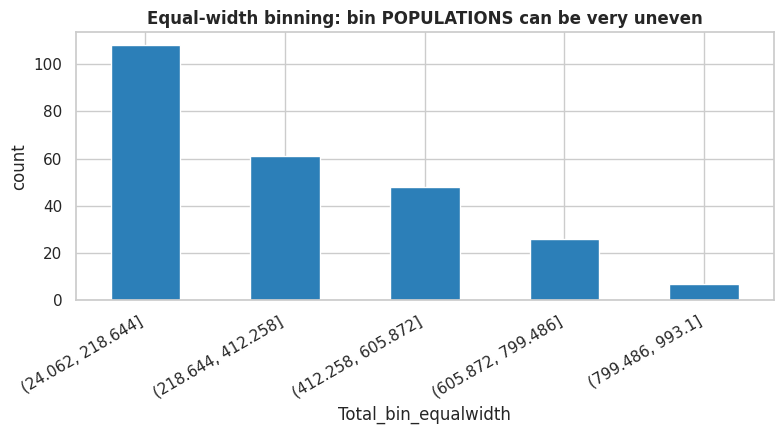

In [3]:
# 🔧 CHANGE THIS: `bins=` sets the boundaries, `labels=` names them.
# Boundaries are (left, right] by default — right-inclusive. Pass right=False to flip that.
df['Total_bin_equalwidth'] = pd.cut(df['Total'], bins=5)
print("Equal-width bins for 'Total' (5 bins):")
print(df['Total_bin_equalwidth'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4.5))
df['Total_bin_equalwidth'].value_counts().sort_index().plot(kind='bar', color='#2c7fb8', ax=ax)
ax.set_title("Equal-width binning: bin POPULATIONS can be very uneven", fontweight='bold')
ax.set_ylabel('count'); plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Equal-frequency / quantile binning (`pd.qcut`)
Instead of equal-width intervals, this splits the data so **each bin has (roughly) the same number of observations**. Great when you want balanced categories, e.g. for a fair "Low/Medium/High" spend tier.

Equal-frequency (quantile) bins for 'Total' (5 bins):
Total_bin_quantile
Very Low     50
Low          50
Medium       50
High         50
Very High    50
Name: count, dtype: int64


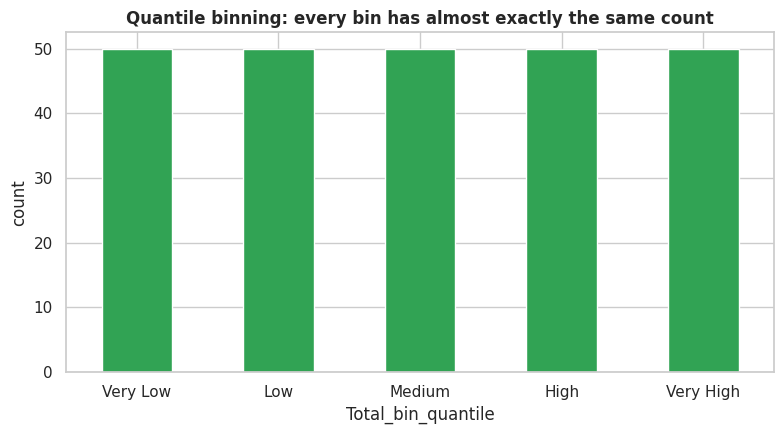

In [4]:
df['Total_bin_quantile'] = pd.qcut(df['Total'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
print("Equal-frequency (quantile) bins for 'Total' (5 bins):")
print(df['Total_bin_quantile'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4.5))
df['Total_bin_quantile'].value_counts().reindex(['Very Low','Low','Medium','High','Very High']).plot(
    kind='bar', color='#31a354', ax=ax)
ax.set_title("Quantile binning: every bin has almost exactly the same count", fontweight='bold')
ax.set_ylabel('count'); plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Custom / domain-driven binning
Sometimes the "right" bin edges come from business logic, not the data itself — e.g. a marketing team's own definition of spend tiers. `pd.cut` lets you supply explicit edges.

In [5]:
custom_bins = [0, 100, 300, 500, np.inf] 
custom_labels = ['Small basket (<$100)', 'Medium basket ($100-300)', 'Large basket ($300-500)', 'Bulk basket ($500+)']
# 🔧 CHANGE THIS: `bins=` sets the boundaries, `labels=` names them.
# Boundaries are (left, right] by default — right-inclusive. Pass right=False to flip that.
df['Total_bin_custom'] = pd.cut(df['Total'], bins=custom_bins, labels=custom_labels)
df['Total_bin_custom'].value_counts().reindex(custom_labels)

Total_bin_custom
Small basket (<$100)        49
Medium basket ($100-300)    91
Large basket ($300-500)     58
Bulk basket ($500+)         52
Name: count, dtype: int64

## 5. K-Means clustering-based binning
Rather than fixing bin edges up front, let a 1-D K-Means clustering find natural groupings in the data itself — bin edges fall wherever the *data's own density* has gaps, not at arbitrary equal-width or equal-frequency points.

In [6]:
from sklearn.cluster import KMeans

k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Total_bin_kmeans'] = km.fit_predict(df[['Total']])

# Relabel cluster IDs in order of increasing centroid value, so labels read low-to-high
centroid_order = np.argsort(km.cluster_centers_.flatten())
relabel_map = {old: new for new, old in enumerate(centroid_order)}
df['Total_bin_kmeans'] = df['Total_bin_kmeans'].map(relabel_map)

bin_ranges = df.groupby('Total_bin_kmeans')['Total'].agg(['min', 'max', 'count']).round(1)
print("K-Means-derived bin boundaries (data-driven, not arbitrary):")
bin_ranges

K-Means-derived bin boundaries (data-driven, not arbitrary):


,min,max,count
Total_bin_kmeans,,,
0,25.0,166.5,81
1,172.2,340.5,69
2,353.1,563.2,61
3,586.9,993.1,39


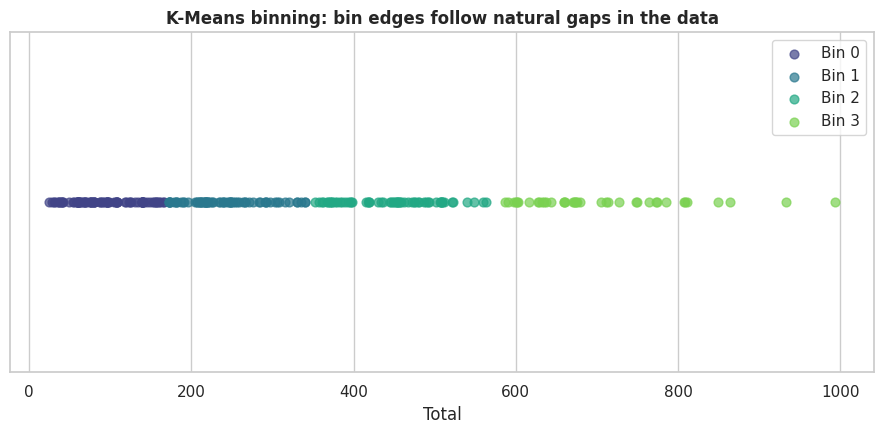

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = sns.color_palette('viridis', k)
for cluster_id in range(k):
    subset = df[df['Total_bin_kmeans'] == cluster_id]
    ax.scatter(subset['Total'], [0]*len(subset), color=colors[cluster_id], label=f'Bin {cluster_id}', s=40, alpha=0.7)
ax.set_yticks([])
ax.set_xlabel('Total')
ax.set_title('K-Means binning: bin edges follow natural gaps in the data', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Supervised (decision-tree-based) binning
All the methods above are **unsupervised** — they only look at the column being binned. If you have a target variable in mind, a shallow decision tree can find bin edges that are maximally informative *for that target* — e.g. binning `Total` in a way that best separates high vs. low `Rating`.

In [8]:
from sklearn.tree import DecisionTreeRegressor, export_text

# A shallow tree (max_depth=3) on a single feature naturally produces a small
# number of split points -- exactly what we want as bin edges.
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=20, random_state=42)
tree.fit(df[['Total']], df['Rating'])

# Extract the actual split thresholds the tree learned
thresholds = sorted(tree.tree_.threshold[tree.tree_.feature != -2])
edges = [-np.inf] + thresholds + [np.inf]
# 🔧 CHANGE THIS: `bins=` sets the boundaries, `labels=` names them.
# Boundaries are (left, right] by default — right-inclusive. Pass right=False to flip that.
df['Total_bin_supervised'] = pd.cut(df['Total'], bins=edges)

print("Decision-tree-derived bin edges (chosen to best predict Rating):")
print(sorted(thresholds))
print("\nAverage Rating per supervised bin (should show a clear step pattern if bins are informative):")
df.groupby('Total_bin_supervised', observed=True)['Rating'].agg(['mean', 'count']).round(2)

Decision-tree-derived bin edges (chosen to best predict Rating):
[np.float64(66.79000091552734), np.float64(257.8000030517578), np.float64(370.94000244140625), np.float64(516.2999877929688), np.float64(659.3200073242188)]

Average Rating per supervised bin (should show a clear step pattern if bins are informative):


,mean,count
Total_bin_supervised,,
"(-inf, 66.79]",6.65,25
"(66.79, 257.8]",5.77,103
"(257.8, 370.94]",6.32,29
"(370.94, 516.3]",6.88,48
"(516.3, 659.32]",6.48,20
"(659.32, inf]",7.45,25


## 7. Comparing all five binning strategies side-by-side

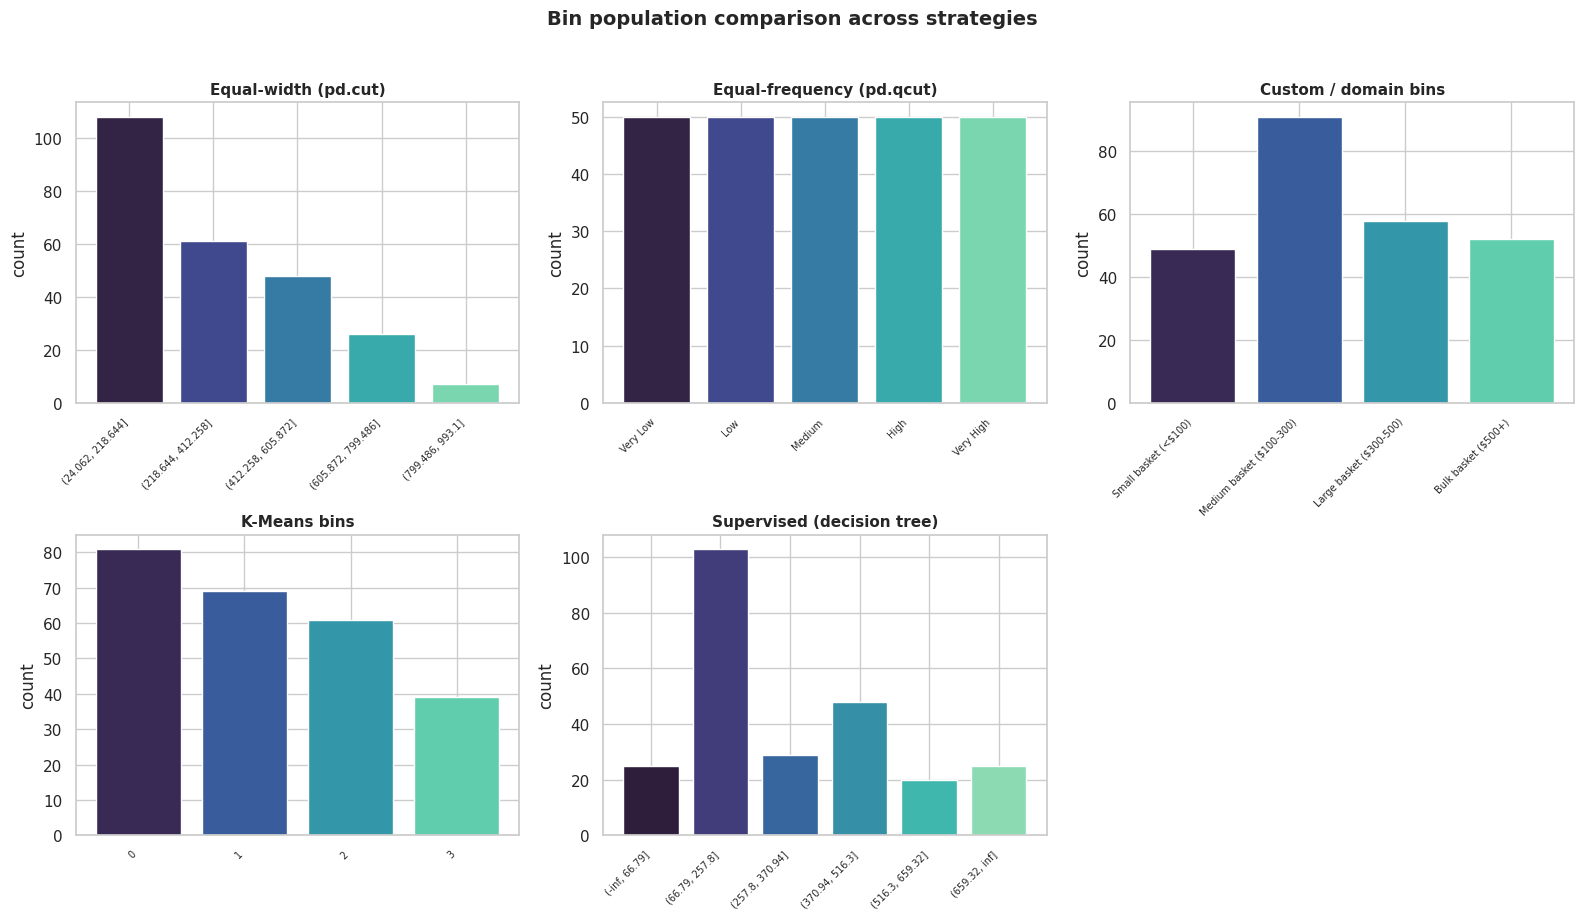

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

strategies = [
    ('Equal-width (pd.cut)', 'Total_bin_equalwidth'),
    ('Equal-frequency (pd.qcut)', 'Total_bin_quantile'),
    ('Custom / domain bins', 'Total_bin_custom'),
    ('K-Means bins', 'Total_bin_kmeans'),
    ('Supervised (decision tree)', 'Total_bin_supervised'),
]
for ax, (title, col) in zip(axes, strategies):
    counts = df[col].value_counts().sort_index()
    ax.bar(range(len(counts)), counts.values, color=sns.color_palette('mako', len(counts)))
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([str(i) for i in counts.index], rotation=45, ha='right', fontsize=7)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('count')

axes[-1].axis('off')
plt.suptitle('Bin population comparison across strategies', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Key takeaways

| Method | Bin edges determined by... | Best for |
|---|---|---|
| Equal-width (`pd.cut`) | Fixed intervals across the value range | Simple, interpretable ranges; fine on roughly-uniform data |
| Equal-frequency (`pd.qcut`) | Data quantiles | Balanced group sizes (e.g. fair percentile tiers) |
| Custom / domain bins | Business/domain knowledge | When stakeholders already have meaningful thresholds in mind |
| K-Means binning | Natural density clusters in the data | Letting the data reveal its own groupings, no target needed |
| Supervised (tree-based) binning | Maximizing predictive power for a target | Feature engineering ahead of a specific modeling task |

Binning always **throws away some information** (exact values become ranges) in exchange for robustness to noise and easier interpretation — choose the bin edges deliberately, not by default.

### ⚡ Beyond the syllabus — choosing cut points you can defend

"Why those bands?" is the follow-up question, and "they looked about right" is not an answer. Four defensible bases: **domain convention** (age brackets a marketing team already uses), **quantiles** (equal group sizes, so every band is comparably reliable), **natural breaks** in the histogram, and **supervised binning** where the cut points are chosen to best separate an outcome. Say which you used and why.

Loaded 'supermarket_sales.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
METHOD                      BAND SIZES                        COMMENT
----------------------------------------------------------------------------------------------------
equal width (cut)           [5, 2, 7, 5]                      bands can be very uneven
equal frequency (qcut)      [5, 5, 4, 5]                      equal counts by construction
business bands              [2, 4, 8, 5]                      defensible; matches how the business thinks
k-means (natural breaks)    [5, 2, 7, 5]                      follows real gaps in the data

The boundaries each method actually chose:
  equal width    : [60.1, 242.0, 423.1, 604.2, 785.4]
  equal frequency: [60.8, 209.6, 457.4, 609.0, 785.4]
  business bands : [0, 100, 300, 600, 'inf']


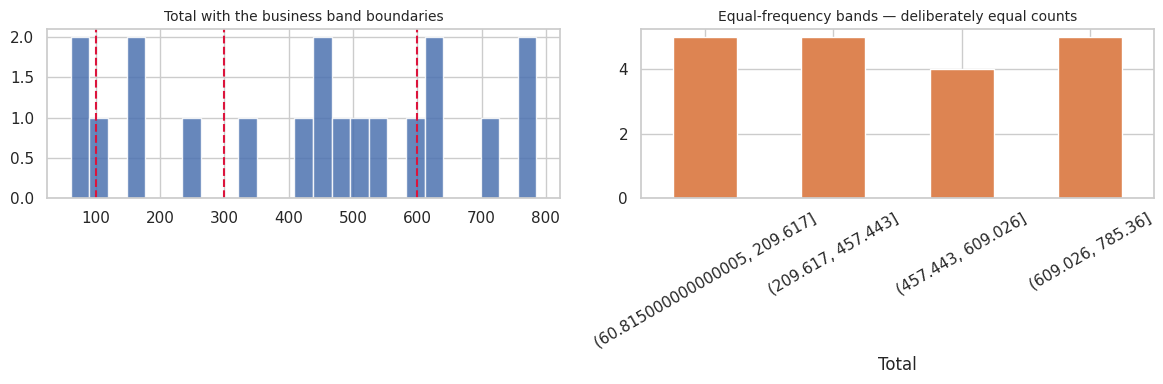

In [10]:
from sklearn.preprocessing import KBinsDiscretizer

sales = load_data('supermarket_sales.csv', rebuild=rebuild_supermarket_sales)
value_col = 'Total' if 'Total' in sales.columns else sales.select_dtypes('number').columns[0]
x = sales[value_col].dropna()

methods = {}

# 1. EQUAL WIDTH — same rupee range per band. Simple; can leave bands nearly empty.
methods['equal width (cut)'] = pd.cut(x, bins=4)

# 2. EQUAL FREQUENCY — same number of transactions per band. Every band is equally reliable.
methods['equal frequency (qcut)'] = pd.qcut(x, q=4, duplicates='drop')

# 3. BUSINESS BANDS — boundaries the business already uses. Most defensible when they exist.
edges = [0, 100, 300, 600, np.inf]                 # 🔧 CHANGE THIS: your organisation's thresholds
methods['business bands'] = pd.cut(x, bins=edges,
                                   labels=['Small', 'Medium', 'Large', 'Very Large'])

# 4. K-MEANS BINNING — let the natural clusters in the data set the boundaries
kmeans_bins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans',
                               subsample=None).fit_transform(x.to_frame()).ravel()
methods['k-means (natural breaks)'] = pd.Series(kmeans_bins, index=x.index).astype(int)

print(f"{'METHOD':<28}{'BAND SIZES':<34}COMMENT")
print("-" * 100)
comments = {'equal width (cut)': 'bands can be very uneven',
            'equal frequency (qcut)': 'equal counts by construction',
            'business bands': 'defensible; matches how the business thinks',
            'k-means (natural breaks)': 'follows real gaps in the data'}
for name, binned in methods.items():
    sizes = binned.value_counts().sort_index().tolist()
    print(f"{name:<28}{str(sizes):<34}{comments[name]}")

print("\nThe boundaries each method actually chose:")
print("  equal width    :", [round(float(i.left), 1) for i in
                             pd.cut(x, bins=4).cat.categories] + [round(float(x.max()), 1)])
print("  equal frequency:", [round(v, 1) for v in x.quantile([0, .25, .5, .75, 1]).tolist()])
print("  business bands :", edges[:-1] + ['inf'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(x, bins=25, color='#4c72b0', alpha=.85)
for e in edges[1:-1]:
    axes[0].axvline(e, color='crimson', ls='--', lw=1.5)
axes[0].set_title(f'{value_col} with the business band boundaries', fontsize=10)
methods['equal frequency (qcut)'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#dd8452')
axes[1].set_title('Equal-frequency bands — deliberately equal counts', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Equal-width bands | `pd.cut(s, bins=4)` |
| Your own boundaries | `pd.cut(s, bins=[0,100,300,np.inf])` |
| Named bands | `pd.cut(s, bins=…, labels=['Low','Mid','High'])` |
| Equal-sized groups | `pd.qcut(s, q=4)` |
| Deciles | `pd.qcut(s, q=10, labels=False)` |
| Handle repeated edges | `pd.qcut(s, q=4, duplicates='drop')` |
| Left-inclusive bands | `pd.cut(s, bins=…, right=False)` |
| Count per band | `binned.value_counts().sort_index()` |
| Bands → numbers | `binned.cat.codes` |
| Natural breaks | `KBinsDiscretizer(strategy='kmeans')` |

### Adapting this in the exam

- 'Create bins/bands/groups/categories from a numeric column' → `pd.cut`.
- 'Equal numbers in each group', 'quartiles', 'deciles' → `pd.qcut`.
- 'Low/Medium/High' → `pd.cut` with `labels=`.
- Always follow the binning with a `value_counts()` so the band sizes are visible.

### Traps that cost marks

- `pd.cut` bands are right-inclusive by default: `(0, 100]` **excludes** 0 and includes 100. Values below the first edge become `NaN`.
- If your `bins` list doesn't reach the maximum value, those rows silently become `NaN`. Use `np.inf` as the last edge.
- `labels=` must have exactly **one fewer** entry than `bins` — n edges make n−1 bands.
- `pd.qcut` fails with 'Bin edges must be unique' when many values are identical. Pass `duplicates='drop'`.
- The result is a `category` dtype, not a string. `.astype(str)` before merging or exporting if that matters.
- In a `groupby` on a categorical, pass `observed=True` or you'll get rows for empty bands.